# 📊 Distributions with Iris Dataset (Python)

Student-friendly notebook to understand distributions and visualization techniques.

## 📦 Setup

Load libraries and dataset.

In [3]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy import stats

# Load iris dataset
iris = load_iris(as_frame=True)
df = iris.frame

# Add species names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# Rename columns for simplicity
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target', 'species']

# Display first rows
df.head()
iris_df=df
df

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [2]:
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import load_iris


# Add species as numeric
iris_df['species'] = iris.target

# Define X and y
X = iris_df.drop(['sepal_length','species','target'], axis=1)
y = iris_df['sepal_length']

# Add intercept
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Show full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sepal_length   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     295.5
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           8.59e-62
Time:                        12:10:01   Log-Likelihood:                -37.321
No. Observations:                 150   AIC:                             82.64
Df Residuals:                     146   BIC:                             94.69
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8560      0.251      7.401   

## 📊 Histogram

Shows the distribution (frequency) of a variable.

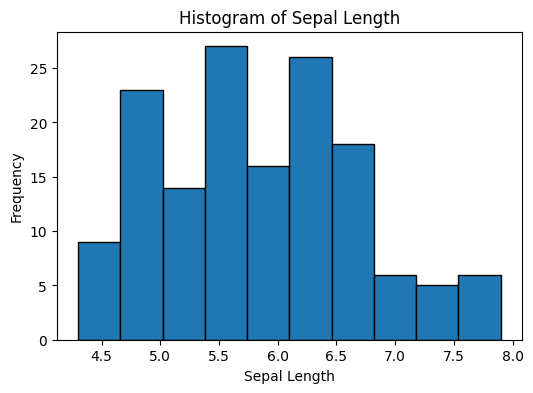

In [2]:
# Histogram of sepal length
plt.figure(figsize=(6,4))
plt.hist(df['sepal_length'], edgecolor='black')

plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")

plt.show()

## 📈 Density Plot

Smooth version of histogram showing distribution shape.

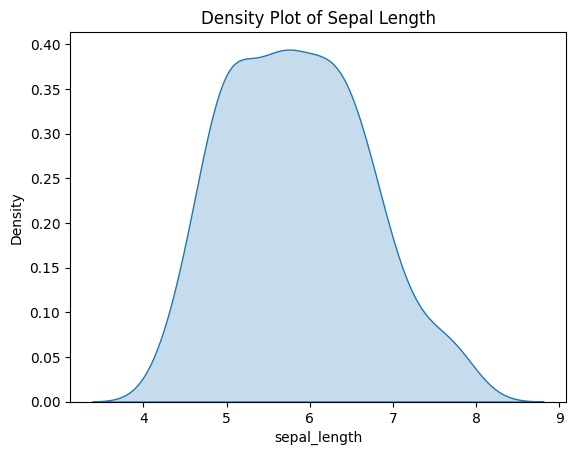

In [3]:
# Density plot
sns.kdeplot(df['sepal_length'], fill=True)

plt.title("Density Plot of Sepal Length")
plt.show()

## 📊 Histogram + Density

Combines histogram and density curve.

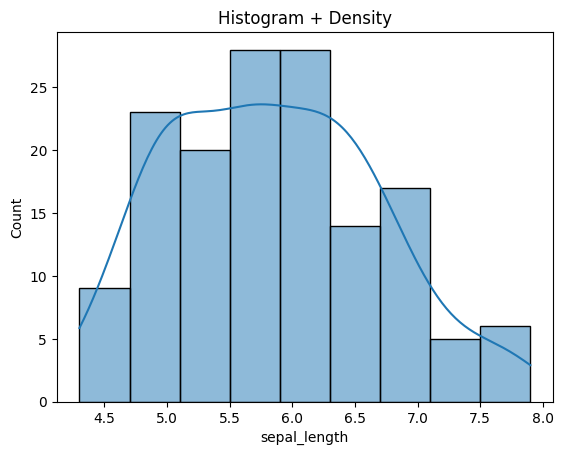

In [4]:
# Histogram with KDE
sns.histplot(df['sepal_length'], kde=True, edgecolor='black')

plt.title("Histogram + Density")
plt.show()

## 📊 Distribution by Species

Compare distributions across categories.

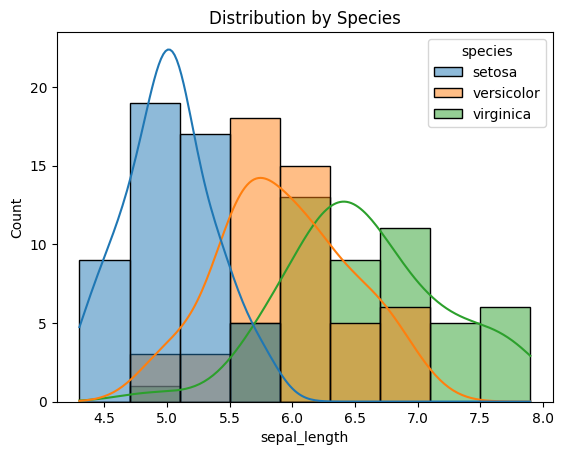

In [5]:
# Histogram by species
sns.histplot(data=df, x='sepal_length', hue='species', kde=True)

plt.title("Distribution by Species")
plt.show()

## 📉 Q-Q Plot

Used to check if data follows a normal distribution.

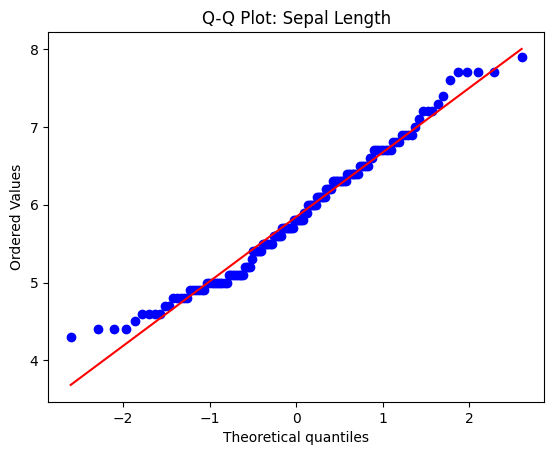

In [6]:
# Q-Q plot
stats.probplot(df['sepal_length'], dist="norm", plot=plt)

plt.title("Q-Q Plot: Sepal Length")
plt.show()

## 📦 Boxplot

Shows median, quartiles, and outliers.

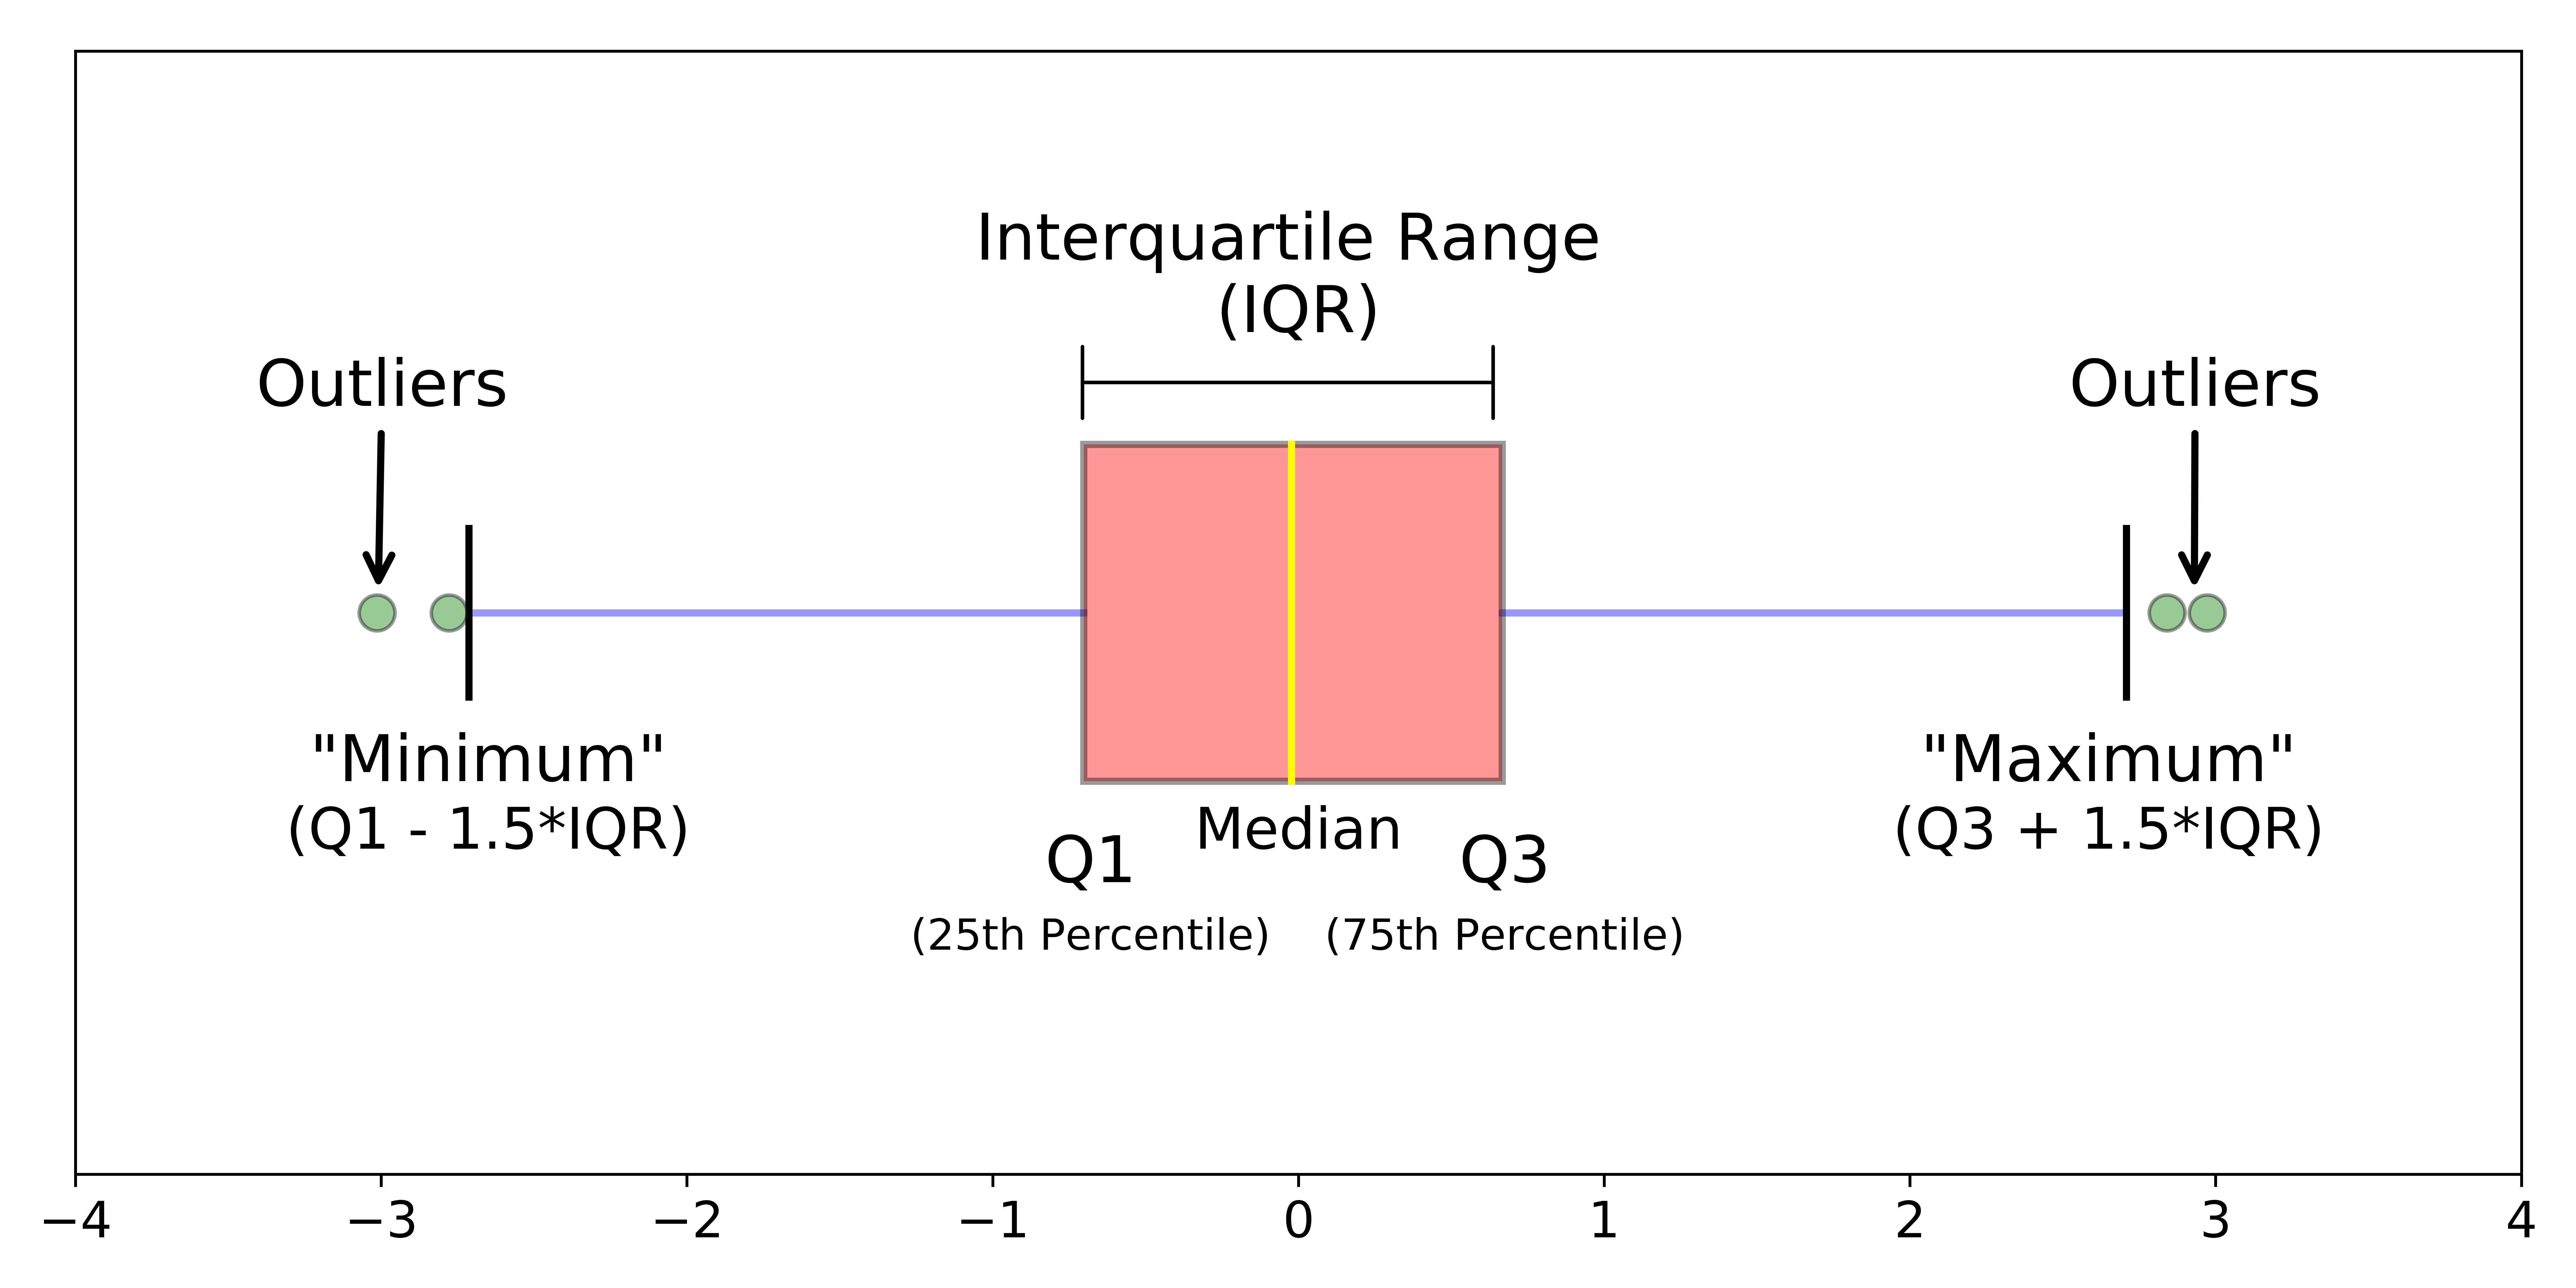

## 📊 Understanding the Boxplot

The boxplot is a graphical summary of the distribution of a numerical variable.

In this case, it shows the distribution of **sepal_length**.

## 📦 Components of the Boxplot

A boxplot contains several important parts:

### 1. Median (Q2)
- The line inside the box
- Represents the middle value (50% of data)

---

### 2. First Quartile (Q1)
- Bottom of the box
- 25% of data is below this value

---

### 3. Third Quartile (Q3)
- Top of the box
- 75% of data is below this value

---

### 4. Interquartile Range (IQR)
- IQR = Q3 − Q1
- Represents the spread of the middle 50% of data

---

### 5. Whiskers
- Extend from the box to show the range of the data (excluding outliers)

---

### 6. Outliers
- Individual points outside the whiskers
- Represent unusually high or low values

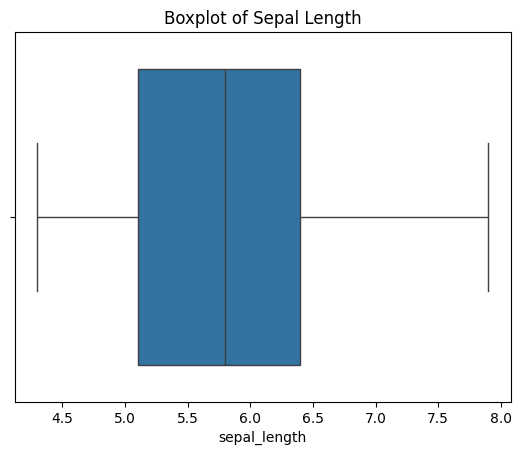

In [6]:
# Boxplot
sns.boxplot(x=df['sepal_length'])

plt.title("Boxplot of Sepal Length")
plt.show()

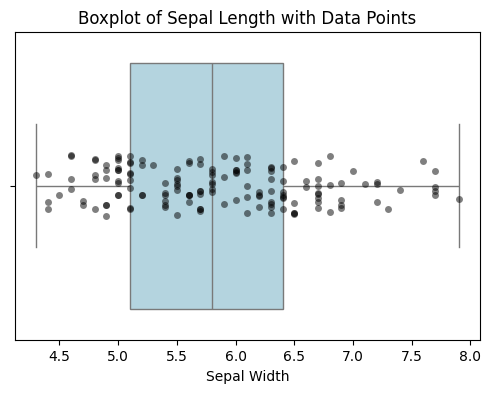

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Boxplot
sns.boxplot(x='sepal_length', data=df, color='lightblue')

# Add dots (all observations)
sns.stripplot(x='sepal_length', data=df, color='black', alpha=0.5, jitter=True)

plt.title("Boxplot of Sepal Length with Data Points")
plt.xlabel("Sepal Width")

plt.show()

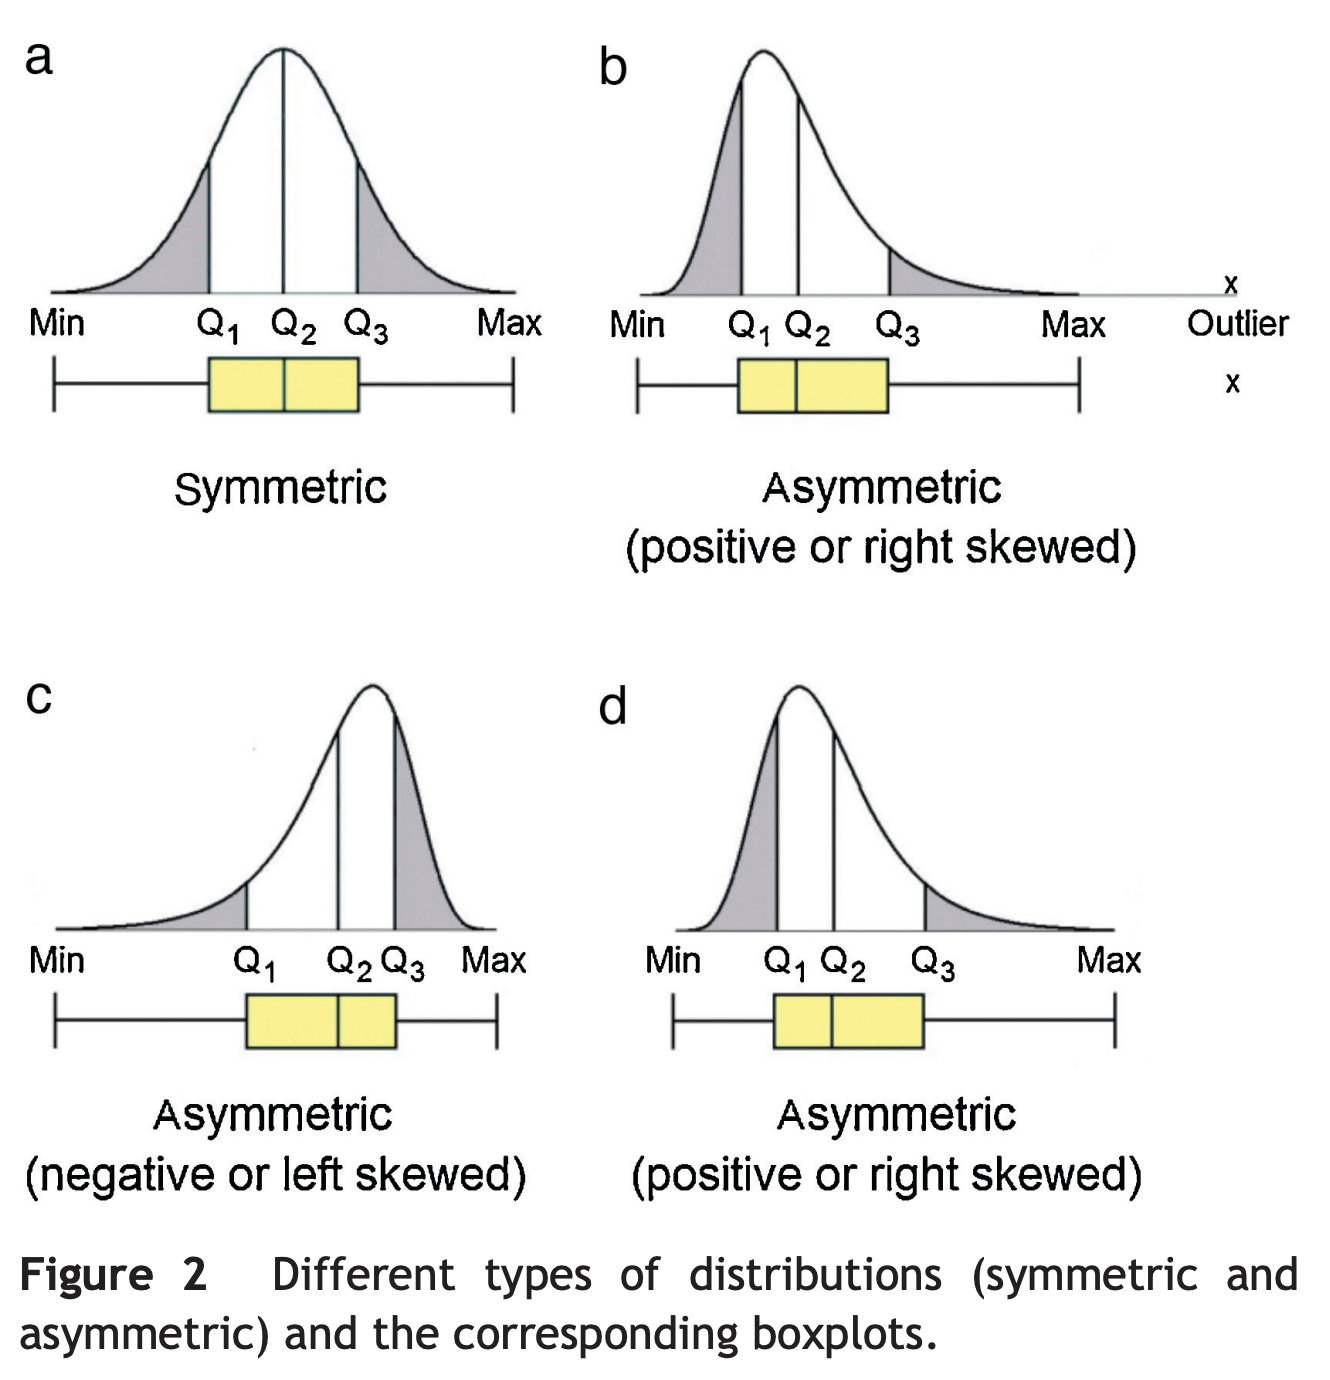


## 📦 Boxplot by Species

## Questions 
### a) Does the sepal_length significantly difference by species? 
### b) A cliam has been made that the sepal_length significantly difference by species.


## 1. Visula answer

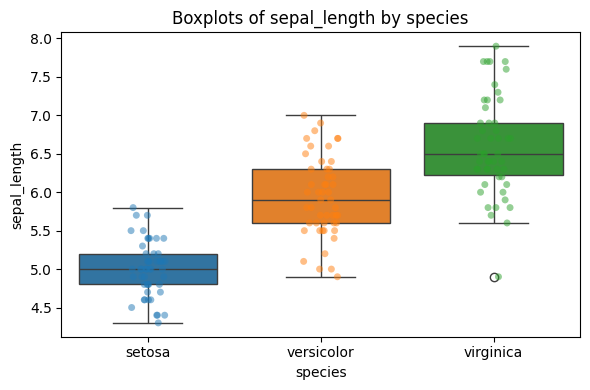

In [2]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="species", y="sepal_length", hue="species", legend=False)
# Add dots (all observations)
sns.stripplot(data=df, x="species", y="sepal_length", hue="species", legend=False, alpha=0.5, jitter=True)

plt.xlabel("species")
plt.ylabel("sepal_length")
plt.title("Boxplots of sepal_length by species")
plt.tight_layout()
plt.show()

## 📊 Visual Analysis

The boxplot below shows the distribution of sepal_length for each species.

- Setosa appears to have smaller values
- Versicolor has medium values
- Virginica has larger values

👉 This suggests there may be differences between species, but we need statistical testing to confirm.

## Visual ≠ proof → we need statistics

## 2. Statistical Answer (ANOVA test)

### Since:

### Independent variable = species (categorical)
### Dependent variable = sepal_length (numeric)

👉 Use One-Way ANOVA

## 🧪 Hypotheses

### Null Hypothesis (H₀)
The mean sepal_length is the same for all species.

H₀: μ_setosa = μ_versicolor = μ_virginica

---

### Alternative Hypothesis (H₁)
At least one species has a different mean sepal_length.

H₁: At least one mean is different

In [7]:
from scipy import stats

# separate groups
setosa = df[df['species'] == 'setosa']['sepal_length']
versicolor = df[df['species'] == 'versicolor']['sepal_length']
virginica = df[df['species'] == 'virginica']['sepal_length']

# ANOVA test
f_stat, p_value = stats.f_oneway(setosa, versicolor)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 119.26450218450468
p-value: 1.6696691907693826e-31


## ✅ Conclusion

If the p-value is less than 0.05:

👉 We reject the null hypothesis.

This means that **sepal_length significantly differs between species**.

✔ The claim is supported.

## 💡 Note

ANOVA tells us that there is a difference, but it does not tell us **which species are different**.

To find that, we use a post-hoc test such as Tukey’s test.

Post-hoc (Tukey’s test.)

## Post-hoc (Tukey’s test) Tukey’s test.

## 📈 Post-hoc Hypotheses

For each pair of species, Tukey’s test checks:

- **H₀:** The two species have the same mean sepal_length
- **H₁:** The two species have different mean sepal_length

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['sepal_length'],
                          groups=df['species'],
                          alpha=0.05)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------


## 📝 Conclusion After Post-hoc Test

The ANOVA test showed that sepal_length differs by species.  
The Tukey post-hoc test helps us determine exactly which species pairs are significantly different.

## 🔗 Violin Plot

Shows relationships between multiple variables.

## 📊 Violin Plot

A violin plot shows both:
- Summary statistics (like a boxplot)
- The distribution shape (density)

### How to interpret:
- Wide areas → many data points
- Narrow areas → few data points
- The middle line → median
- Shape → tells us if data is skewed or has multiple peaks

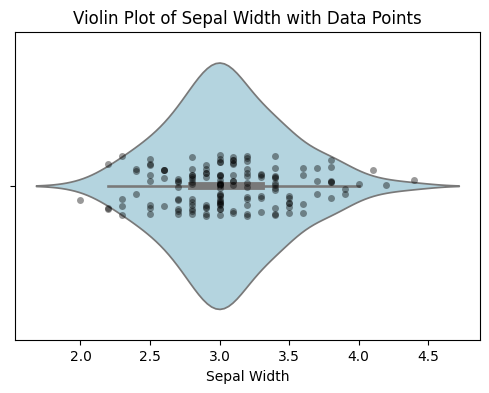

In [14]:
plt.figure(figsize=(6, 4))

sns.violinplot(x='sepal_width', data=df, inner='box', color='lightblue')

sns.stripplot(x='sepal_width', data=df, color='black', alpha=0.4)

plt.title("Violin Plot of Sepal Width with Data Points")
plt.xlabel("Sepal Width")

plt.show()

/tmp/ipykernel_55/4184455572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y='sepal_length', data=df, inner='box', palette='pastel')


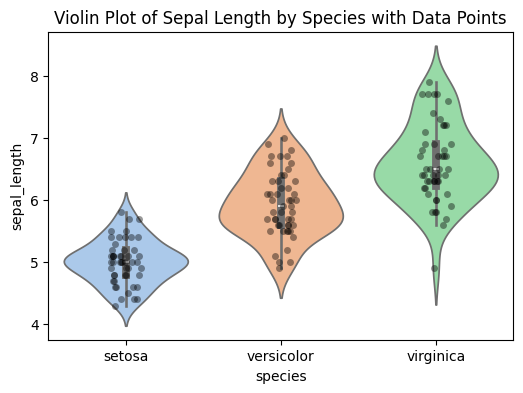

In [16]:
plt.figure(figsize=(6, 4))

sns.violinplot(x='species', y='sepal_length', data=df, inner='box', palette='pastel')

# add data points
sns.stripplot(x='species', y='sepal_length', data=df, color='black', alpha=0.4, jitter=True)

plt.title("Violin Plot of Sepal Length by Species with Data Points")
plt.show()